# Visualization Chart Components Walkthrough

This notebook demonstrates how to use the new `stats_transformer.visualization.charts` library. These are standalone, highly reusable plot components designed specifically for structured data (DataFrames).

They abstract away complex matplotlib and seaborn boilerplate while ensuring consistent styling and label formatting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import all the new chart components
from stats_transformer.visualization.charts import (
    CoefficientBarChart,
    GroupedBarChart,
    StackedBarChart,
    TimeSeriesPlot,
    IRFPlot,
    FacetedTimeSeries,
    BinnedScatterPlot,
    ScatterWithRegression,
    CorrelationHeatmap
)

# Setting seed for reproducibility of dummy data
np.random.seed(42)

## 1. Bar Charts

### CoefficientBarChart
Used to display a single group of regression coefficients with standard error bars and significance stars.

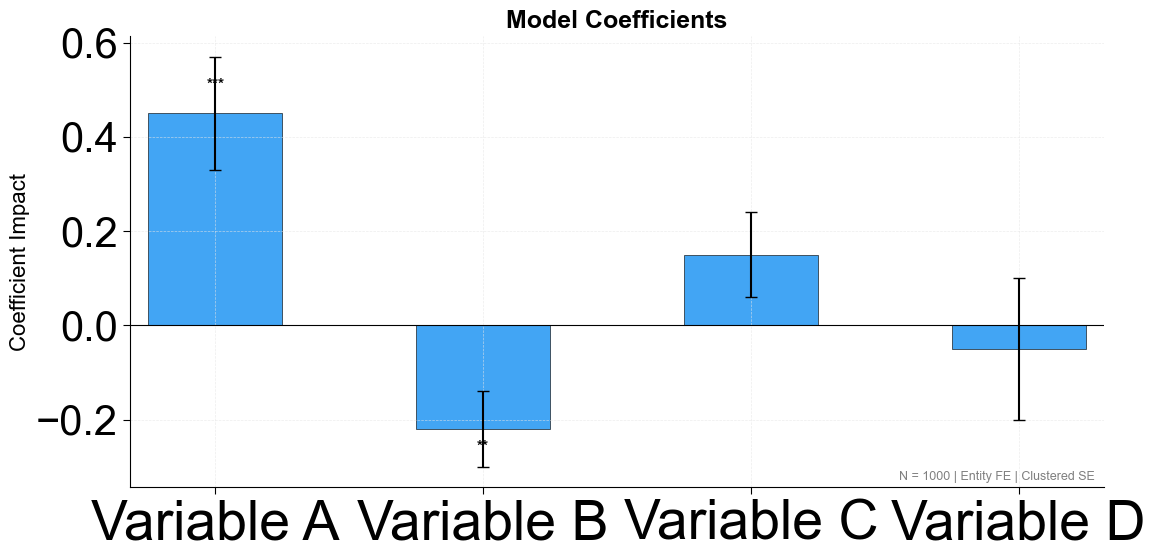

In [2]:
chart = CoefficientBarChart()

fig, ax = chart.plot(
    labels=["Variable A", "Variable B", "Variable C", "Variable D"],
    coefficients=[0.45, -0.22, 0.15, -0.05],
    std_errors=[0.12, 0.08, 0.09, 0.15],
    p_values=[0.001, 0.04, 0.15, 0.85],
    ylabel="Coefficient Impact",
    title="Model Coefficients",
    footer="N = 1000 | Entity FE | Clustered SE"
)
plt.show()

### GroupedBarChart
Used to compare multiple groups side-by-side.

In [4]:
df_grouped = pd.DataFrame({
    'Model': ['Baseline', 'Baseline', 'Baseline', 'Robust', 'Robust', 'Robust'],
    'Variable': ['Var X', 'Var Y', 'Var Z', 'Var X', 'Var Y', 'Var Z'],
    'Coef': [0.5, 0.3, 0.1, 0.45, 0.35, 0.05],
    'SE': [0.1, 0.1, 0.05, 0.12, 0.11, 0.06],
    'Pval': [0.001, 0.02, 0.15, 0.005, 0.01, 0.4]
})
df_grouped.head(2)

,Model,Variable,Coef,SE,Pval
0,Baseline,Var X,0.5,0.1,0.001
1,Baseline,Var Y,0.3,0.1,0.020


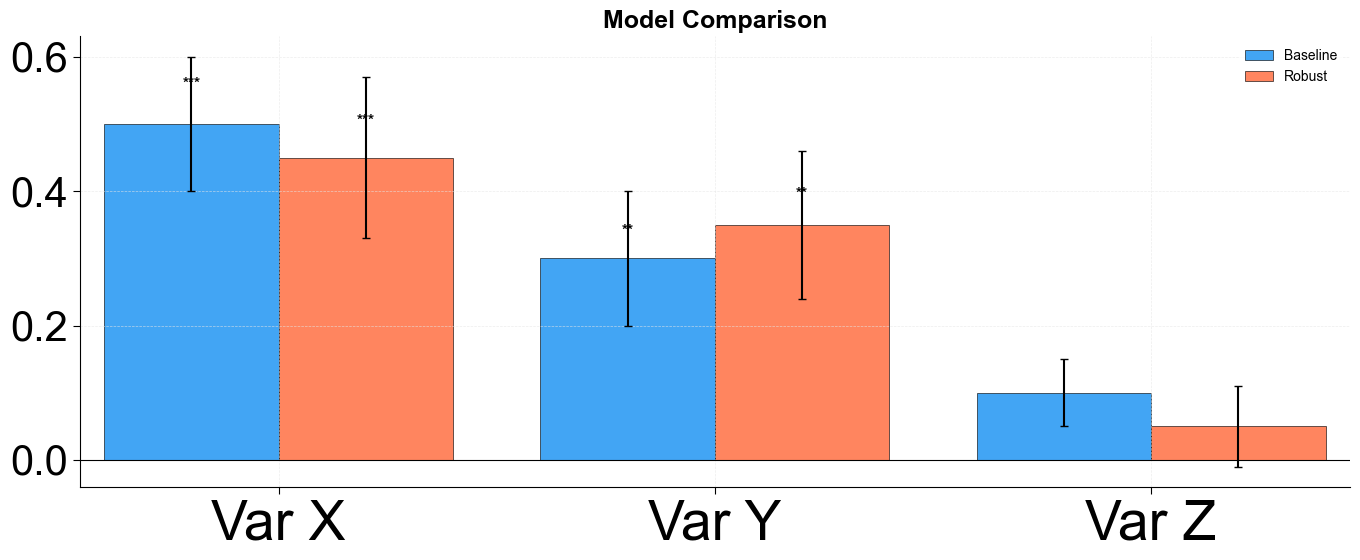

In [ ]:
chart = GroupedBarChart()
fig, ax = chart.plot(
    df=df_grouped, 
    x_col='Variable', 
    y_col='Coef', 
    group_col='Model', 
    error_col='SE', 
    pval_col='Pval',
    title="Model Comparison"
)
plt.show()

### StackedBarChart
Used to show the composition of a value over categories.

In [7]:
df_stacked = pd.DataFrame({
    'Year': [2020, 2021, 2022, 2023],
    'Positive Mentions': [120, 150, 90, 200],
    'Negative Mentions': [50, 40, 110, 30],
    'Neutral Mentions': [200, 210, 180, 250]
})
df_stacked.head(2)

,Year,Positive Mentions,Negative Mentions,Neutral Mentions
0,2020,120,50,200
1,2021,150,40,210


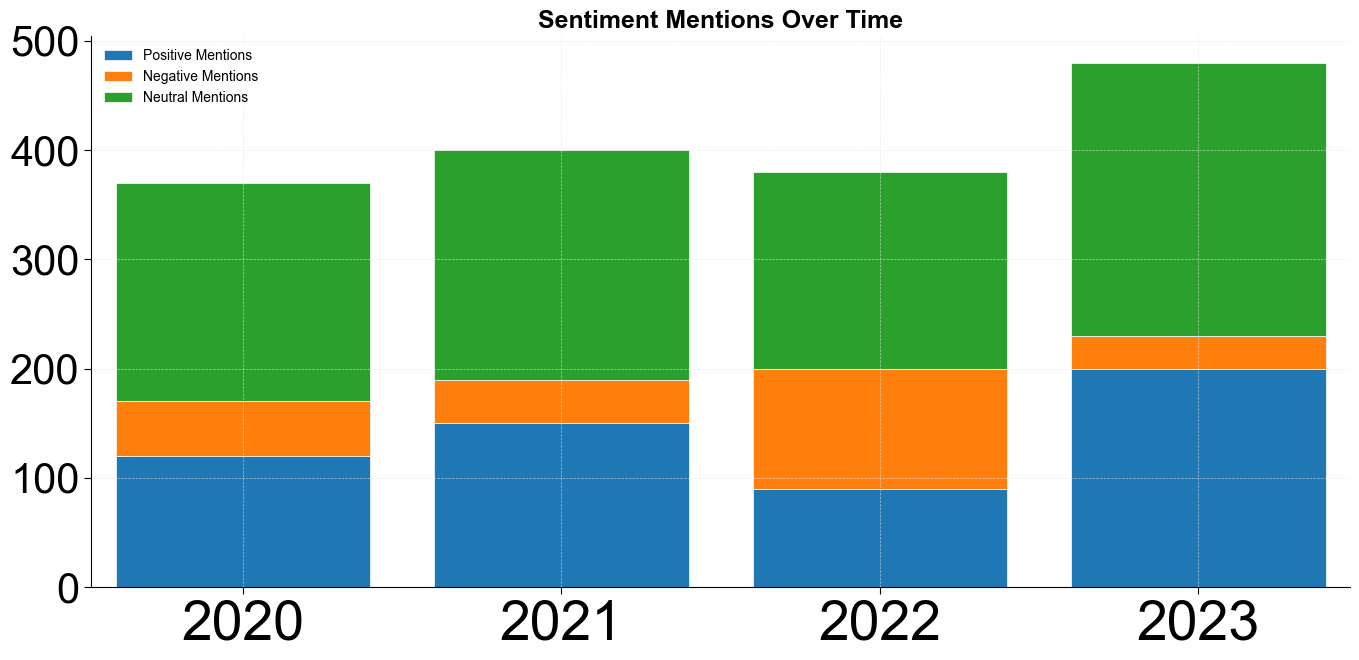

In [8]:

chart = StackedBarChart()
fig, ax = chart.plot(
    df=df_stacked, 
    x_col='Year', 
    y_cols=['Positive Mentions', 'Negative Mentions', 'Neutral Mentions'],
    title="Sentiment Mentions Over Time"
)
plt.show()

## 2. Time Series Charts

### TimeSeriesPlot
Standard time series plot for one or more variables, with optional confidence intervals.

In [11]:
dates = pd.date_range('2020-01-01', periods=20, freq='ME')
df_ts = pd.DataFrame({
    'Date': dates,
    'Index_A': np.cumsum(np.random.randn(20)) + 10,
    'Index_A_lower': np.nan,  # Optional CI lower bound
    'Index_A_upper': np.nan,  # Optional CI upper bound
    'Index_B': np.cumsum(np.random.randn(20)) + 5
})
df_ts.head(2)

,Date,Index_A,Index_A_lower,Index_A_upper,Index_B
0,2020-01-31,10.496714,NaN,NaN,6.465649
1,2020-02-29,10.358450,NaN,NaN,6.239872


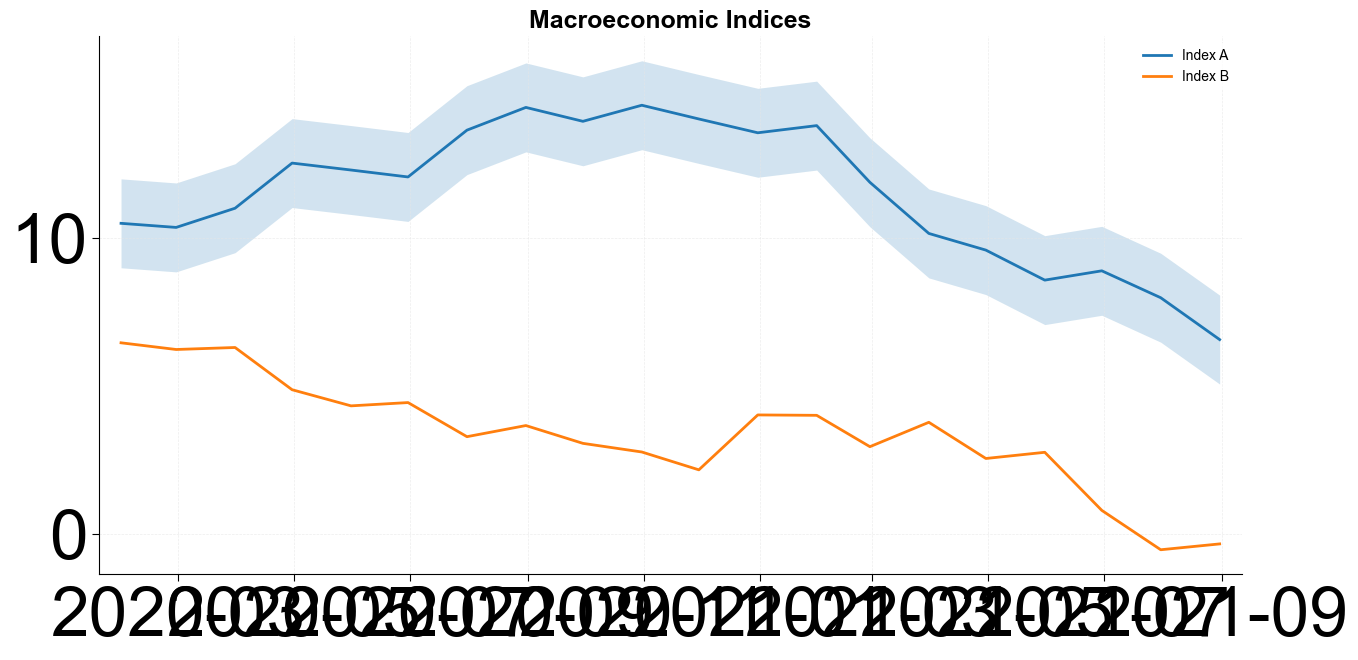

In [12]:
# Adding mock confidence bands to Index A
df_ts['Index_A_lower'] = df_ts['Index_A'] - 1.5
df_ts['Index_A_upper'] = df_ts['Index_A'] + 1.5

chart = TimeSeriesPlot()
fig, ax = chart.plot(
    df=df_ts, 
    x_col='Date', 
    y_cols=['Index_A', 'Index_B'],
    ci_lower_cols=['Index_A_lower', None],
    ci_upper_cols=['Index_A_upper', None],
    title="Macroeconomic Indices"
)
plt.show()

### IRFPlot
Impulse Response Function plots, faceted by the shock variable. Automatically grids the variables.

In [13]:
horizons = list(range(13))
vars_list = ['Shock 1', 'Shock 2', 'Shock 3', 'Shock 4']
irf_data = []
for v in vars_list:
    for h in horizons:
        coef = np.sin(h / 2.0) * np.exp(-h / 4.0) if v in ['Shock 1', 'Shock 3'] else -np.sin(h / 3.0) * np.exp(-h / 5.0)
        irf_data.append({
            'Variable': v,
            'Horizon': h,
            'Coef': coef,
            'Lower': coef - 0.2,
            'Upper': coef + 0.2
        })
df_irf = pd.DataFrame(irf_data)
df_irf.head(2)

,Variable,Horizon,Coef,Lower,Upper
0,Shock 1,0,0.000000,-0.200000,0.200000
1,Shock 1,1,0.373377,0.173377,0.573377


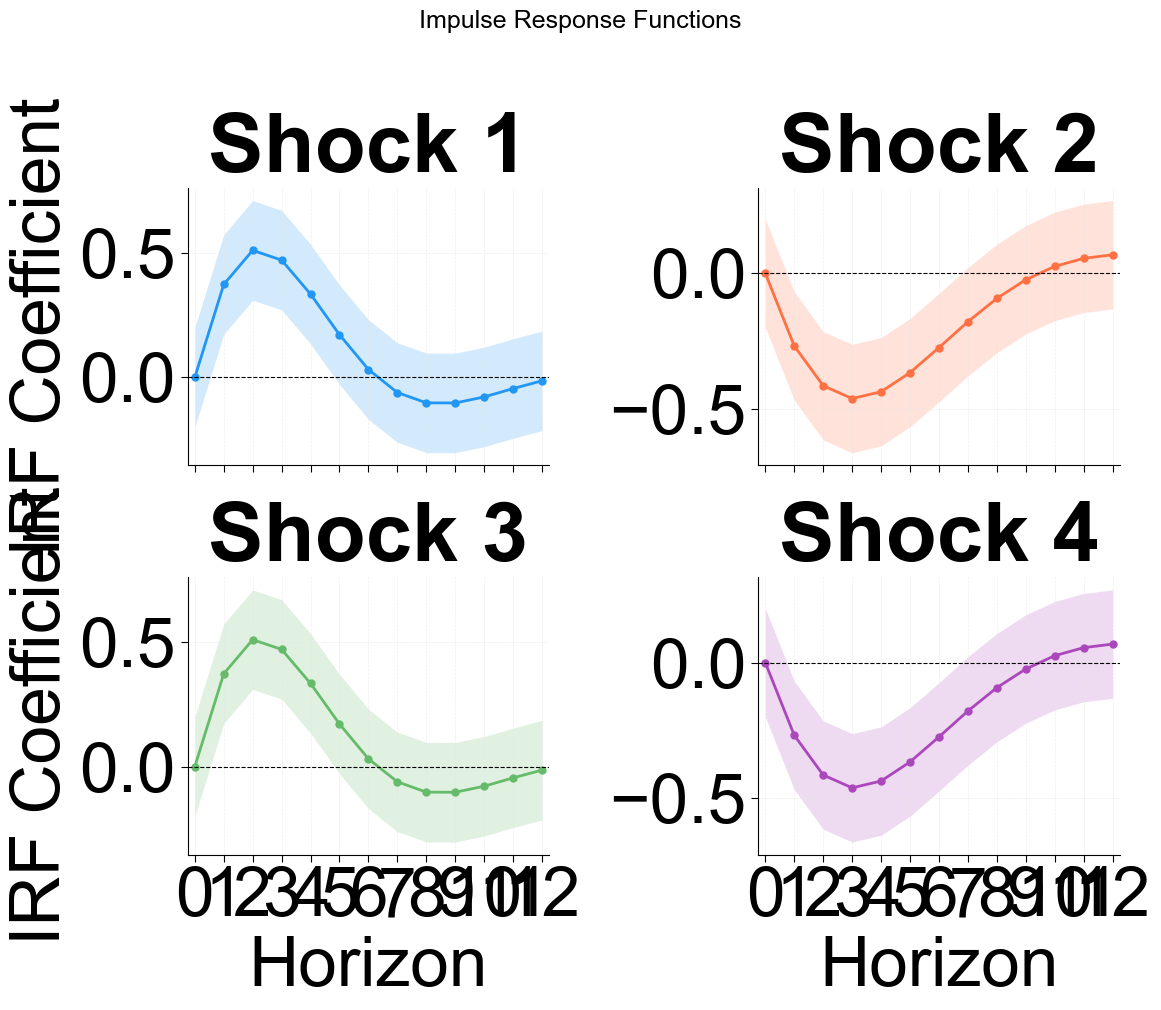

In [ ]:
chart = IRFPlot()
fig, axes = chart.plot(
    df=df_irf,
    horizon_col='Horizon',
    coef_col='Coef',
    ci_lower_col='Lower',
    ci_upper_col='Upper',
    group_col='Variable',
    title="Impulse Response Functions"
)
plt.show()

### FacetedTimeSeries
Small multiples grid plotting time series across multiple entities (e.g. countries).

In [16]:
entities = ['USA', 'UK', 'Japan', 'Euro Area', 'Canada', 'Australia']
dates = pd.date_range('2015-01-01', periods=50, freq='QE')
panel_data = []
for e in entities:
    trend = np.cumsum(np.random.randn(50)) * 0.5
    for i, d in enumerate(dates):
        panel_data.append({'Country': e, 'Date': d, 'Inflation': 2.0 + trend[i] + np.random.randn()*0.2})
df_panel = pd.DataFrame(panel_data)
df_panel.head(2)

,Country,Date,Inflation
0,USA,2015-03-31,2.388649
1,USA,2015-06-30,2.648646


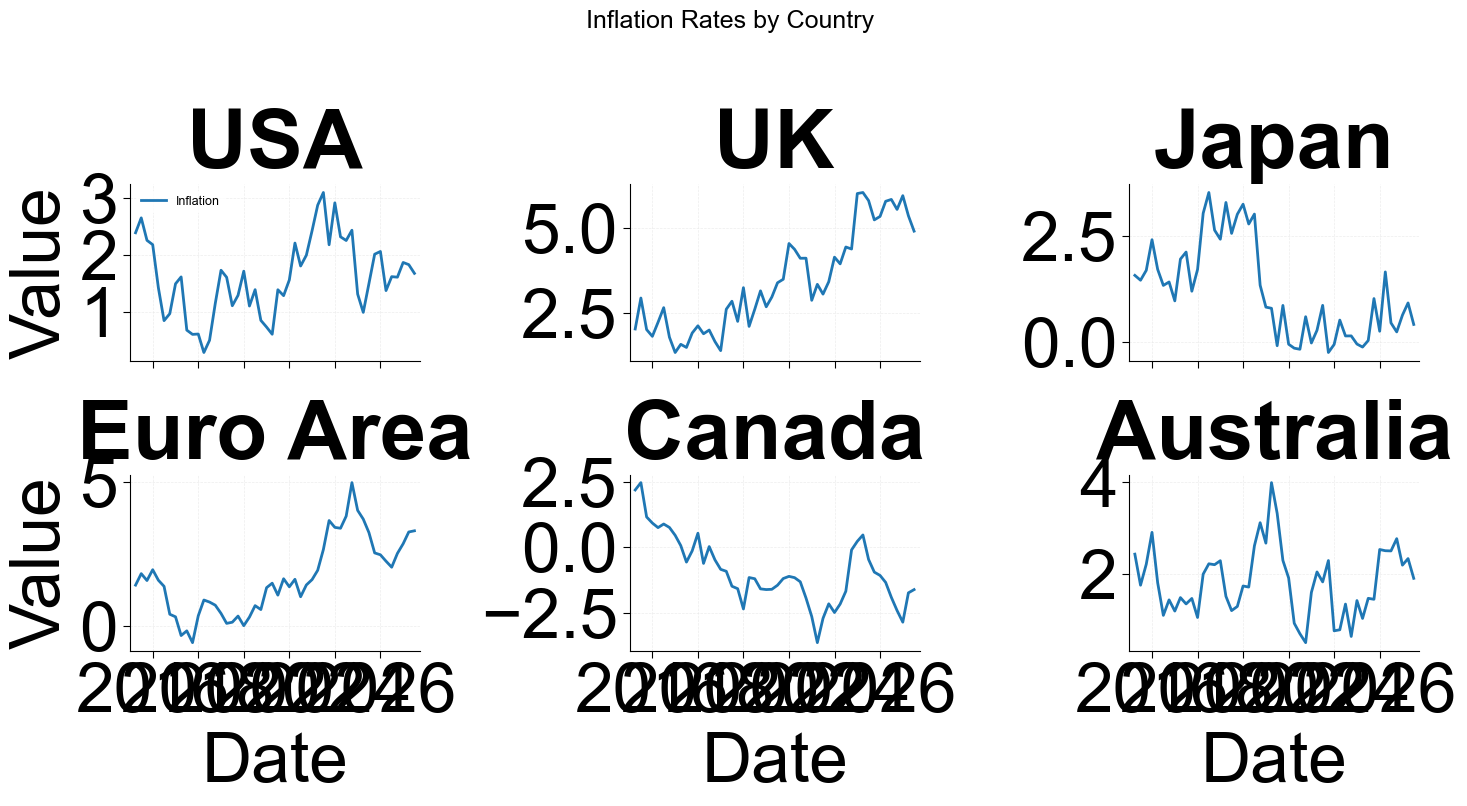

In [18]:
chart = FacetedTimeSeries()
fig, axes = chart.plot(
    df=df_panel,
    date_col='Date',
    value_cols=['Inflation'],
    facet_col='Country',
    title="Inflation Rates by Country"
)
plt.show()

## 3. Scatter Plots

### BinnedScatterPlot
Plots raw scattered data alongside binned means and an OLS trendline. Excellent for visualizing relationships in large, noisy panel datasets.

In [19]:
x = np.random.randn(500)
y = 2.5 * x + np.random.randn(500) * 4
df_scatter = pd.DataFrame({'Sentiment': x, 'Policy Rate Change': y})
df_scatter.head(2)

,Sentiment,Policy Rate Change
0,-0.335785,-2.029716
1,1.669022,9.675381


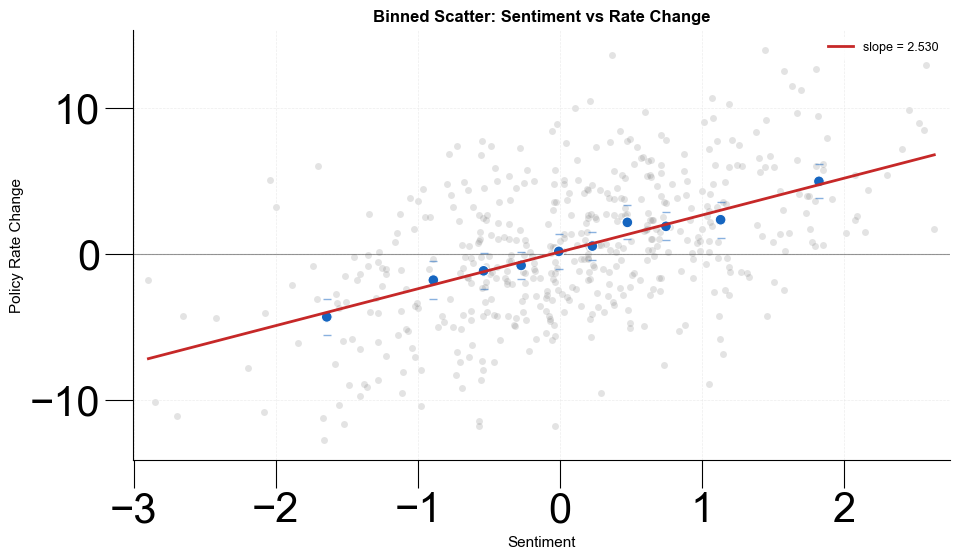

In [20]:
chart = BinnedScatterPlot()
fig, ax = chart.plot(
    df=df_scatter,
    x_col='Sentiment',
    y_col='Policy Rate Change',
    n_bins=10,
    title="Binned Scatter: Sentiment vs Rate Change"
)
plt.show()

### ScatterWithRegression
Standard scatter plot overlaid with a seaborn regression line and a correlation annotation.

In [21]:
x2 = np.random.rand(100) * 10
y2 = -1.5 * x2 + np.random.randn(100) * 2 + 15
df_scatter2 = pd.DataFrame({'Variable 1': x2, 'Variable 2': y2})
df_scatter2.head(2)

,Variable 1,Variable 2
0,0.834641,14.482613
1,8.824164,5.440122


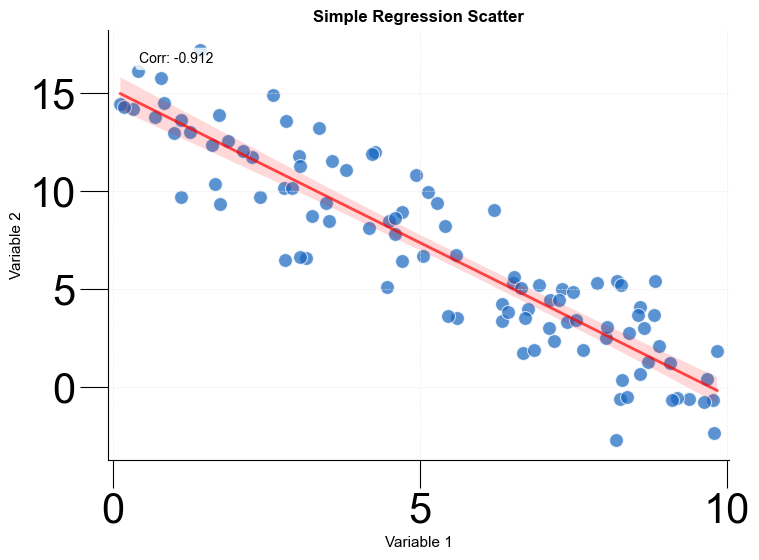

In [23]:
chart = ScatterWithRegression()
fig, ax = chart.plot(
    df=df_scatter2,
    x_col='Variable 1',
    y_col='Variable 2',
    title="Simple Regression Scatter"
)
plt.show()

## 4. Heatmaps

### CorrelationHeatmap
Generates a lower-triangle masked correlation heatmap.

In [25]:
df_heat = pd.DataFrame(np.random.randn(100, 5), columns=['GDP Growth', 'Inflation', 'Unemployment', 'Interest Rate', 'Sentiment'])
# Induce some correlation
df_heat['Inflation'] = df_heat['Interest Rate'] * 0.6 + np.random.randn(100) * 0.5
df_heat['Sentiment'] = df_heat['GDP Growth'] * 0.8 - df_heat['Unemployment'] * 0.5 + np.random.randn(100)
df_heat.head(2)

,GDP Growth,Inflation,Unemployment,Interest Rate,Sentiment
0,2.056544,-0.810732,0.473632,-0.926381,1.481099
1,-0.918687,0.602711,-0.295090,0.975817,-0.998897


Could not apply style default (resolved to default.mplstyle): 'default.mplstyle' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`). Using default.


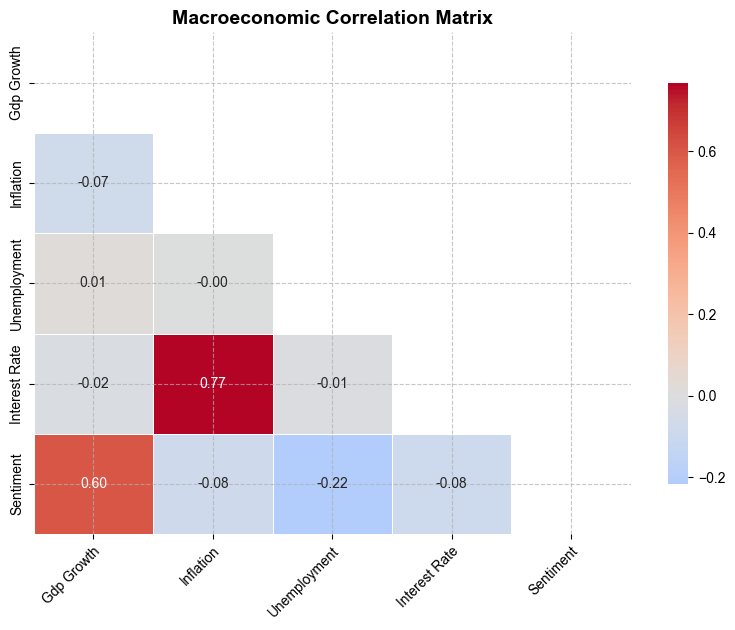

In [26]:

chart = CorrelationHeatmap()
fig, ax = chart.plot(
    df=df_heat,
    title="Macroeconomic Correlation Matrix"
)
plt.show()